<a target="_blank" href="https://colab.research.google.com/github/joshi98kishan/understanding_gflownet/blob/main/face_emoji_gfn.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

As mentioned in the blog, code here is taken from emmanuel's [Colab](https://colab.research.google.com/drive/1fUMwgu2OhYpQagpzU5mhe9_Esib3Q2VR?usp=sharing) but with one small tweak. So, first go through his notebook to understand about target distribution, environment, state representation, neural network, evaluation etc., which are exactly the same except the training loop and the batch-size used here. 

Also, in the blog and in this notebook, we have only used flow-matching loss but there are other losses too like "Trajectory Balance" loss as mentioned in his Colab.



In [1]:
import numpy as np
from tqdm.notebook import tqdm
import matplotlib.pyplot as pp

import torch
import torch.nn as nn
from torch.distributions.categorical import Categorical

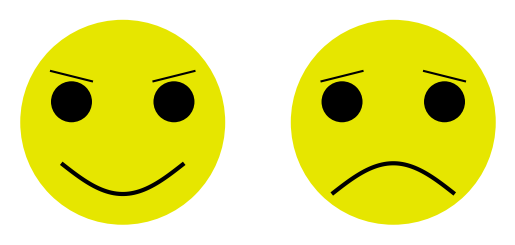

In [2]:
base_face = lambda: (pp.gca().add_patch(pp.Circle((0.5,0.5),0.5,fc=(.9,.9,0))),
                     pp.gca().add_patch(pp.Circle((0.25,0.6),0.1,fc=(0,0,0))),
                     pp.gca().add_patch(pp.Circle((0.75,0.6),0.1,fc=(0,0,0))))
patches = {
  'smile': lambda: pp.gca().add_patch(pp.Polygon(np.stack([np.linspace(0.2,0.8), 0.3-np.sin(np.linspace(0,3.14))*0.15]).T, closed=False, fill=False, lw=3)),
  'frown': lambda: pp.gca().add_patch(pp.Polygon(np.stack([np.linspace(0.2,0.8), 0.15+np.sin(np.linspace(0,3.14))*0.15]).T, closed=False, fill=False, lw=3)),
  'left_eb_down': lambda: pp.gca().add_line(pp.Line2D([0.15, 0.35], [0.75,0.7], color=(0,0,0))),
  'right_eb_down': lambda: pp.gca().add_line(pp.Line2D([0.65, 0.85], [0.7,0.75], color=(0,0,0))),
  'left_eb_up': lambda: pp.gca().add_line(pp.Line2D([0.15, 0.35], [0.7,0.75], color=(0,0,0))),
  'right_eb_up': lambda: pp.gca().add_line(pp.Line2D([0.65, 0.85], [0.75,0.7], color=(0,0,0))),
}

sorted_keys = sorted(patches.keys())

def draw_face(face):
  base_face()
  for i in face:
    patches[i]()
  pp.axis('scaled')
  pp.axis('off')

f, ax = pp.subplots(1,2)
pp.sca(ax[0])
draw_face(['smile', 'left_eb_down', 'right_eb_down'])
pp.sca(ax[1])
draw_face(['frown', 'left_eb_up', 'right_eb_up'])

In [3]:
def has_overlap(face):
  # Can't have two overlapping eyebrows!
  if 'left_eb_down' in face and 'left_eb_up' in face:
    return True
  if 'right_eb_down' in face and 'right_eb_up' in face:
    return True
  # Can't have two overlapping mouths!
  if 'smile' in face and 'frown' in face:
    return True
  return False

def face_reward(face):
  if has_overlap(face):
    return 0
  eyebrows = 'left_eb_down', 'left_eb_up', 'right_eb_down', 'right_eb_up'
  # Must have exactly two eyebrows
  if sum([i in face for i in eyebrows]) != 2:
    return 0
  # We want twice as many happy faces as sad faces so here we give a reward of 2 for smiles
  if 'smile' in face:
    return 2
  if 'frown' in face:
    return 1  # and a reward of 1 for frowns
  # If we reach this point, there's no mouth
  return 0

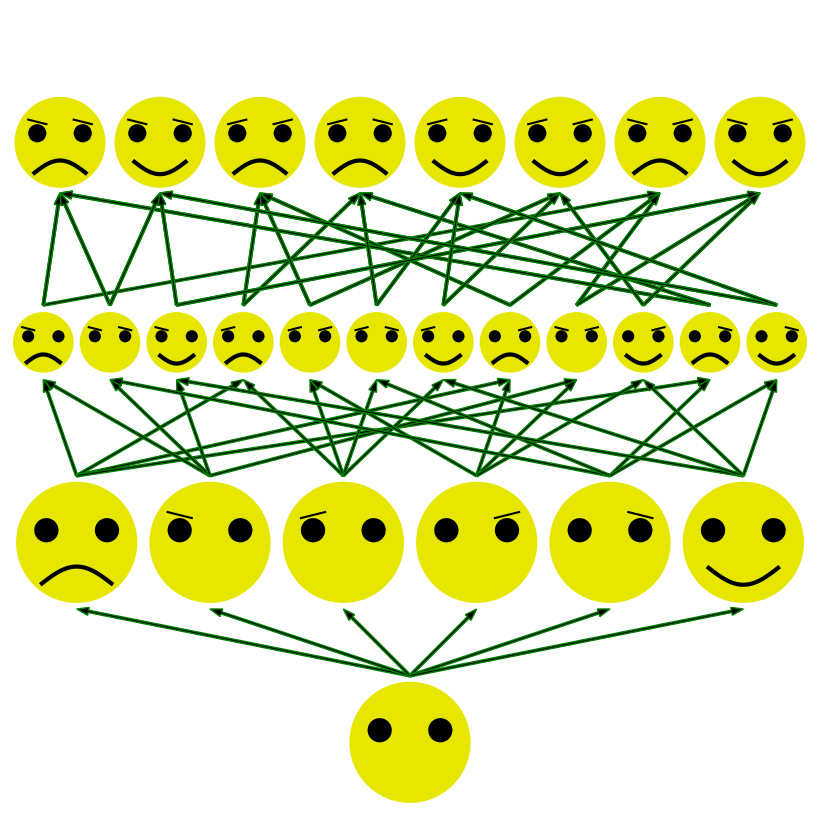

In [4]:
#@title
enumerated_states = []
transitions = []
def recursively_enumerate(s):
  if has_overlap(s):
    return
  for i in sorted_keys:
    if i not in s:
      recursively_enumerate(s+[i])
  enumerated_states.append(s)
  transitions.append((s[:-1], s))
recursively_enumerate([])
unique = []
for i in map(set, enumerated_states):
  if i not in unique:
    unique.append(i)
enumerated_states = sorted(map(tuple, unique))

lens = [len([i for i in enumerated_states if len(i) == j]) for j in range(4)]
levels = [sorted([i for i in enumerated_states if len(i) == j]) for j in range(4)]

f = pp.figure(figsize=(8, 8))
def face_hash(face):
  return tuple([i in face for i in sorted_keys])
face2pos = {}
for i, (level, L) in enumerate(zip(levels, lens)):
  for j, face in enumerate(level):
    ax = f.add_axes([j/L, i/4, 1/L, 1/6])
    draw_face(face)
    face2pos[face_hash(face)] = (j/L+0.5/L, i/4)
ax = f.add_axes([0,0,1,1])
pp.sca(ax)
pp.gca().set_facecolor((0,0,0,0))
pp.xlim(0,1)
pp.ylim(0,1)
for a, b in transitions[1:]:
  pa, pb = face2pos[face_hash(a)], face2pos[face_hash(b)]
  if not len(b): continue
  lb = int(pb[1] * 4)
  la = int(pa[1] * 4)
  ws = [1/6,1/6,0.13,0.11]
  pp.arrow(pa[0],pa[1]+ws[la],pb[0]-pa[0],pb[1]-pa[1]-ws[lb], head_width=0.01, width=0.003, ec=(0.,0.5,0),fc=(0,0,0),
           length_includes_head=True)
  pp.axis('off')


In [5]:
# We first define how the model will view a face, i.e. how to encode a face in
# a tensor
def face_to_tensor(face):
  return torch.tensor([i in face for i in sorted_keys]).float()

def face_parents(state):
  parent_states = []  # states that are parents of state
  parent_actions = []  # actions that lead from those parents to state
  for face_part in state:
    # For each face part, there is a parent without that part
    parent_states.append([i for i in state if i != face_part])
    # The action to get there is the corresponding index of that face part
    parent_actions.append(sorted_keys.index(face_part))
  return parent_states, parent_actions

class FlowModel(nn.Module):
  def __init__(self, num_hid):
    super().__init__()
    # We encoded the current state as binary vector, for each patch the associated
    # dimension is either 0 or 1 depending on the absence or precense of that patch.
    # Therefore the input dimension is 6 for the 6 patches.
    self.mlp = nn.Sequential(nn.Linear(6, num_hid), nn.LeakyReLU(),
                             # We also output 6 numbers, since there are up to
                             # 6 possible actions (and thus child states), but we
                             # will mask those outputs for patches that are
                             # already there.
                             nn.Linear(num_hid, 6))
  def forward(self, x):
    # We take the exponential to get positive numbers, since flows must be positive,
    # and multiply by (1 - x) to give 0 flow to actions we know we can't take
    # (in this case, x[i] is 1 if a feature is already there, so we know we
    # can't add it again).
    F = self.mlp(x).exp() * (1 - x)
    return F

In [6]:
def calc_state_loss(model, state):
    """Calculate loss for the given state. """
    
    parent_states, parent_actions = face_parents(state)
  
    # And compute the edge flows F(s, a) of each parent
    px = torch.stack([face_to_tensor(p) for p in parent_states])
    pa = torch.tensor(parent_actions).long()
    
    parent_edge_flow_preds = model(px)[torch.arange(len(parent_states)), pa]

    # Now we need to compute the reward and F(s, a) of the current state,
    if len(state) == 3:
      # If we've built a complete face, we're done, so the reward is > 0
      # (unless the face is invalid)
      reward = face_reward(state)
      
      # This is a terminal state. Hence, no children, which we can simulate by setting its edge flow predictions to zero.
      edge_flow_prediction = torch.zeros(6)
    else:
      # Otherwise we keep going, and compute F(s, a)
      reward = 0
      edge_flow_prediction = model(face_to_tensor(state))

    # The loss as per the equation above
    flow_mismatch = (parent_edge_flow_preds.sum() - edge_flow_prediction.sum() - reward).pow(2)

    return flow_mismatch

def evaluate_gfn(model, num_samples, disable_progress = True):
    """Evaluate GFlowNet by sampling according to given sample size `num_samples`."""
   
    samples = []
    rewards = []
    for i in tqdm(range(num_samples), disable=disable_progress):
        state = []
        
        for t in range(3):
            edge_flow_prediction = model(face_to_tensor(state))
            policy = edge_flow_prediction / edge_flow_prediction.sum()
            # Sample the action
            action = Categorical(probs=policy).sample()
            # "Go" to the next state
            state = state + [sorted_keys[action]]

        samples.append(state)
        rewards.append(face_reward(state))


    rewards = np.array(rewards)


    valid_faces_ratio =  sum(rewards>0)/num_samples
    smiley_faces_ratio = len([face for face in samples if 'smile' in face])/num_samples
    frown_faces_ratio = len([face for face in samples if 'frown' in face])/num_samples

    # print('ratio of valid faces: ', sum(rewards>0)/num_samples)
    # print('ratio of smiley face: ', len([face for face in samples if 'smile' in face])/num_samples)
    # print('ratio of frown face: ', len([face for face in samples if 'frown' in face])/num_samples)

    
    return valid_faces_ratio, smiley_faces_ratio, frown_faces_ratio, samples
    

In [7]:
# Store all possible states in the dictionary, level wise.

previous_level = [[]]
states_dict = {}

states_dict[0] = previous_level

for level in range(1, 4):
    level_states = []
    for state in previous_level:    
        for fpart in sorted_keys:
            if (fpart not in state) and sorted(state + [fpart]) not in level_states:
                level_states.append(sorted(state + [fpart]))


    states_dict[level] = level_states
    previous_level = level_states


In [8]:
epochs = 4_000
F_sa = FlowModel(512)
opt = torch.optim.Adam(F_sa.parameters(), 3e-4)

In [9]:
losses = []
valid_faces_ratios = []
smiley_faces_ratios = []
frown_faces_ratios = []


for epoch in tqdm(range(epochs)):
    # calculate all state losses and accumulate it in `loss` variable. 
    # This is akin to full-batch loss where `states_dict` is considered as training dataset.
    loss = 0
    for level, level_states in states_dict.items():
        if level==0:
            continue
        for state in level_states:
            loss += calc_state_loss(F_sa, state)

    
    losses.append(loss.item())
    loss.backward()
    opt.step()
    opt.zero_grad()

    valid_faces_ratio, smiley_faces_ratio, frown_faces_ratio, _ = evaluate_gfn(F_sa, 100)
    valid_faces_ratios.append(valid_faces_ratio)
    smiley_faces_ratios.append(smiley_faces_ratio)
    frown_faces_ratios.append(frown_faces_ratio)

    

  0%|          | 0/4000 [00:00<?, ?it/s]

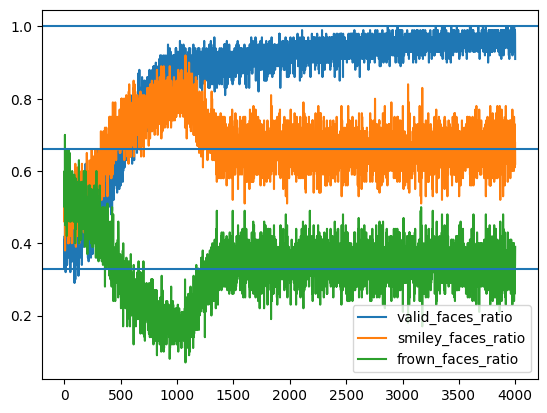

In [10]:
# We can see, all the three ratios converges to their correct values (mentioned via horizontal lines).
pp.plot(valid_faces_ratios, label='valid_faces_ratio')
pp.plot(smiley_faces_ratios, label='smiley_faces_ratio')
pp.plot(frown_faces_ratios, label='frown_faces_ratio')
pp.axhline(y=0.66)
pp.axhline(y=0.33)
pp.axhline(y=1)
pp.legend()

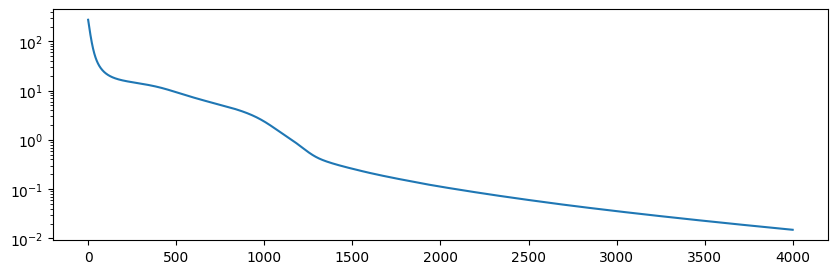

In [11]:
pp.figure(figsize=(10,3))
pp.plot(losses)
pp.yscale('log')
# pp.plot(losses[-100:])

In [12]:
valid_faces_ratio, smiley_faces_ratio, frown_faces_ratio, sampled_faces = evaluate_gfn(F_sa, 10000, False)

print('Ratios corresponding to larger sample size: ')
print(f'Valid Faces Ratio: {valid_faces_ratio}')
print(f'Smiley Faces Ratio: {smiley_faces_ratio}')
print(f'Frown Faces Ratio: {frown_faces_ratio}')


  0%|          | 0/10000 [00:00<?, ?it/s]

Ratios corresponding to larger sample size: 
Valid Faces Ratio: 0.9713
Smiley Faces Ratio: 0.6521
Frown Faces Ratio: 0.3492


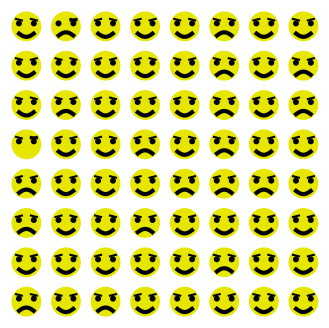

In [13]:
# Some sampled faces
f, ax = pp.subplots(8,8,figsize=(4,4))
for i, face in enumerate(sampled_faces[-64:]):
  pp.sca(ax[i//8,i%8])
  draw_face(face)

In [14]:
# Normalisation constant, which should be equal to 12
F_sa(face_to_tensor([])).sum()

tensor(12.3912, grad_fn=<SumBackward0>)